# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
from sklearn.cluster import KMeans

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

Forma original de la imagen: (2448, 3264, 3)


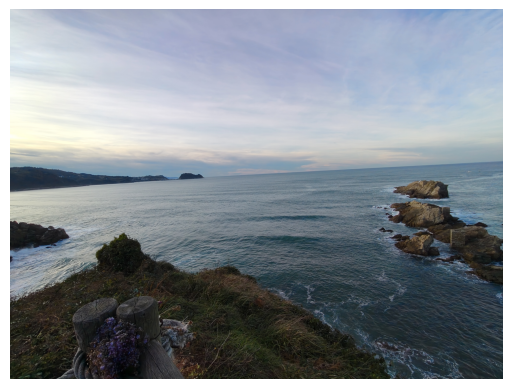

In [4]:
# Carga la imagen

imagen = imread('data/zarautz.jpg') 

# Muestra la imagen y sus dimensiones
plt.imshow(imagen)
plt.axis('off') 

print("Forma original de la imagen:", imagen.shape)


Muestra la imagen para ver que se ha cargado bien

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [5]:
w, h, c = imagen.shape
imagen_transformada = imagen.reshape(w * h, c)
print("Estructura transformada:", imagen_transformada.shape)

Estructura transformada: (7990272, 3)


#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [6]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(imagen_transformada)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [7]:
colores = kmeans.cluster_centers_
etiquetas = kmeans.labels_

# Crear nueva imagen 
nueva_imagen_data = colores[etiquetas]

#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [8]:
nueva_imagen = nueva_imagen_data.reshape(w, h, c).astype(np.uint8)

#### 7. Imprime y guarda en tu ordenador la imagen resultante

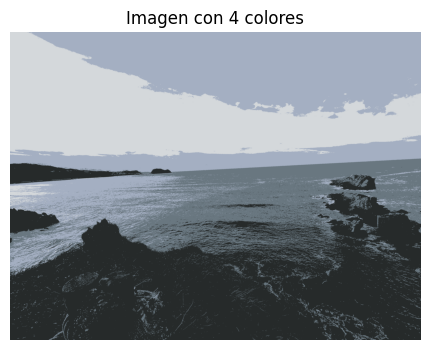

In [9]:
plt.figure(figsize=(6, 4))
plt.imshow(nueva_imagen)
plt.title(f"Imagen con {k} colores")
plt.axis('off')
plt.savefig('imagen_procesada.png')

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [11]:
def agrupar_colores(imagen, n_colores, mostrar=True, guardar_en=None):
   
    w, h, c = imagen.shape
    imagen_plana = imagen.reshape(w * h, c)
    
    # Entrenar K-Means
    kmeans = KMeans(n_clusters=n_colores, random_state=42, n_init=10)
    kmeans.fit(imagen_plana)
    
    # Reconstruir imagen
    colores_comprimidos = kmeans.cluster_centers_[kmeans.labels_]
    imagen_final = colores_comprimidos.reshape(w, h, c).astype(np.uint8)

    if mostrar:
        plt.figure(figsize=(6, 6))
        plt.imshow(imagen_final)
        plt.title(f"Reducida a {n_colores} colores")
        plt.axis('off')
        
    if guardar_en:
        plt.imsave(guardar_en, imagen_final)
        print(f"Imagen guardada en: {guardar_en}")
        
    return imagen_final
